# Analiza jucatorilor de fotbal - sezon 2025/2026

> **Versiune corectata** — target-urile ML sunt variabile reale din date (goluri, gol+assist, +/-90, Save%), nu scoruri compozite construite din aceleasi features. Astfel se elimina data leakage-ul care producea R² = 1.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor
)
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

print('Bibliotecile au fost importate cu succes')

Bibliotecile au fost importate cu succes


## 1. Incarcarea si curatarea datelor

In [2]:
df = pd.read_csv('players_data-2025_2026.csv')
print(f'Datele au fost incarcate. Baza de date are {df.shape[0]} jucatori si {df.shape[1]} coloane.')
display(df.head())

Datele au fost incarcate. Baza de date are 2751 jucatori si 102 coloane.


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,25.0,2000.0,32,26,...,2,0,0,18,47,5,36,14,22,0
1,2,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,2,1,...,0,0,0,2,1,0,3,2,2,0
2,3,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,20.0,2006.0,20,4,...,0,0,0,5,3,2,26,3,3,0
3,4,Himad Abdelli,dz ALG,MF,Marseille,fr Ligue 1,26.0,1999.0,7,1,...,1,0,0,3,0,0,1,1,1,0
4,5,Himad Abdelli,dz ALG,MF,Angers,fr Ligue 1,26.0,1999.0,13,11,...,1,0,0,16,12,1,9,13,17,0


In [3]:
print('--- Informatii generale ---')
df.info()
print('\n--- Valori lipsa per coloana (top 15) ---')
print(df.isnull().sum()[df.isnull().sum() > 0].head(15))

--- Informatii generale ---
<class 'pandas.DataFrame'>
RangeIndex: 2751 entries, 0 to 2750
Columns: 102 entries, Rk to OG
dtypes: float64(41), int64(40), str(21)
memory usage: 2.1 MB

--- Valori lipsa per coloana (top 15) ---
Nation                    2
Age                       1
Born                      1
Rk_stats_keeper        2576
Nation_stats_keeper    2576
Pos_stats_keeper       2576
Comp_stats_keeper      2576
Age_stats_keeper       2576
Born_stats_keeper      2576
MP_stats_keeper        2576
Starts_stats_keeper    2576
Min_stats_keeper       2576
90s_stats_keeper       2576
GA                     2576
GA90                   2576
dtype: int64


In [4]:
# unii jucatori apar cu doua pozitii (ex: "MF,FW"), pastram doar prima
df['Pos'] = df['Pos'].apply(lambda x: x.split(',')[0] if isinstance(x, str) else x)

jucatori_initial = len(df)
df = df[df['Min'] >= 900]
print(f'Am eliminat {jucatori_initial - len(df)} jucatori cu prea putine minute jucate.')

# FBref genereaza coloane duplicate la join-uri, le stergem
cols_de_sters = [c for c in df.columns if any(s in c for s in [
    '_stats_keeper', '_stats_shooting', '_stats_playing_time', '_stats_misc'
])]
df = df.drop(columns=cols_de_sters, errors='ignore')
df = df.drop(columns=['Rk'], errors='ignore')
df = df.dropna(subset=['Player', 'Pos', 'Min'])
# Eliminam duplicatele (jucatori transferati apar de 2 ori in FBref)
df = df.sort_values('Min', ascending=False).drop_duplicates(subset='Player', keep='first')

# coloana Nation vine ca "eng ENG", vrem doar "ENG"
df['Nation'] = df['Nation'].apply(lambda x: x.split(' ')[-1] if isinstance(x, str) else x)
df['Comp']   = df['Comp'].apply(lambda x: ' '.join(x.split(' ')[1:]) if isinstance(x, str) else x)
df['Age']    = df['Age'].astype(float).astype('Int64')
df['Born']   = df['Born'].astype(float).astype('Int64')

print(f'\nBaza de date curatata a ramas cu {len(df)} jucatori gata pentru analiza.')
print(f'Distributie pe pozitii:\n{df["Pos"].value_counts()}')

Am eliminat 1334 jucatori cu prea putine minute jucate.

Baza de date curatata a ramas cu 1413 jucatori gata pentru analiza.
Distributie pe pozitii:
Pos
MF    630
DF    484
FW    190
GK    109
Name: count, dtype: int64


## 2. Explorarea datelor (EDA)

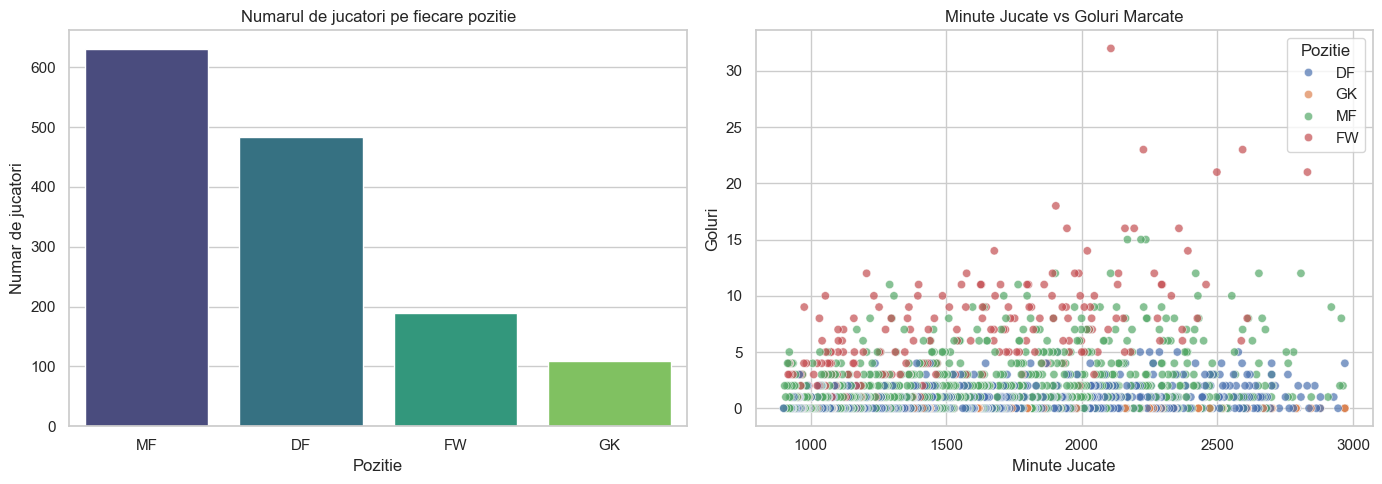

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='Pos', order=df['Pos'].value_counts().index,
              palette='viridis', ax=axes[0])
axes[0].set_title('Numarul de jucatori pe fiecare pozitie')
axes[0].set_xlabel('Pozitie')
axes[0].set_ylabel('Numar de jucatori')

sns.scatterplot(data=df, x='Min', y='Gls', hue='Pos', alpha=0.7, ax=axes[1])
axes[1].set_title('Minute Jucate vs Goluri Marcate')
axes[1].set_xlabel('Minute Jucate')
axes[1].set_ylabel('Goluri')
axes[1].legend(title='Pozitie')

plt.tight_layout()
plt.savefig("grafic_eda.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
df.to_csv('players-curatat.csv', index=False)
print("Fisierul curatat a fost salvat cu succes ca 'players-curatat.csv'.")

Fisierul curatat a fost salvat cu succes ca 'players-curatat.csv'.


## 3. Ingineria caracteristicilor

> **Nota importanta despre design:** Features-urile si target-urile sunt complet separate.
> - Features = statistici de *proces* (cum joaca jucatorul: suturi, tackle, centrari, disciplina)
> - Target = statistica *rezultat* reala din date (goluri, gol+assist, +/-90, Save%)
>
> Aceasta separare elimina data leakage-ul si produce R² realist (0.4–0.8 in loc de 1.0).

In [10]:
_90s = df['90s'].replace(0, np.nan)

# --- Features de proces ---
df['Sh_90']          = df['Sh'].fillna(0) / _90s
df['SoT_Rate']       = df['SoT'].fillna(0) / df['Sh'].fillna(1).replace(0, 1)
df['Def_Actions_90'] = (df['TklW'].fillna(0) + df['Int'].fillna(0)) / _90s
df['Fls_90']         = df['Fls'].fillna(0) / _90s
df['Crs_90']         = df['Crs'].fillna(0) / _90s
df['Cards_90']       = (df['CrdY'].fillna(0) + df['CrdR'].fillna(0) * 3) / _90s
df['PlusMinus_90']   = df['+/-90'].fillna(0)
df['CS_Rate']        = df['CS'].fillna(0) / df['MP'].replace(0, np.nan)
df['PKsv_Rate']      = df['PKsv'].fillna(0) / df['PKA'].replace(0, np.nan).fillna(1).replace(0, 1)
df['GA90']           = df['GA90'].fillna(df['GA90'].median())
df['SoTA_90']        = df['SoTA'].fillna(0) / _90s
df['onGA_90']        = df['onGA'].fillna(0) / _90s
df['onG_90']         = df['onG'].fillna(0) / _90s
df['PPM']            = df['PPM'].fillna(0)
df['Ast_90']         = df['Ast'].fillna(0) / _90s
df['Off_90']         = df['Off'].fillna(0) / _90s
df['Fld_90']         = df['Fld'].fillna(0) / _90s
df['TklW_90']        = df['TklW'].fillna(0) / _90s
df['Int_90']         = df['Int'].fillna(0) / _90s
df['MinPct']         = df['Min%'].fillna(0)

print("Features create cu succes!")
print("\nTarget-uri ML (variabile reale din date):")
print("  FW -> Gls_90 : goluri non-penalty per 90 min")
print("  MF -> G+A    : goluri + assisturi (sezon intreg)")
print("  DF -> +/-90  : impactul echipei cand e pe teren, per 90 min")
print("  GK -> Save%  : procentaj salvari")

Features create cu succes!

Target-uri ML (variabile reale din date):
  FW -> Gls_90 : goluri non-penalty per 90 min
  MF -> G+A    : goluri + assisturi (sezon intreg)
  DF -> +/-90  : impactul echipei cand e pe teren, per 90 min
  GK -> Save%  : procentaj salvari


## 4. Implementare și comparare algoritmi ML

**De ce aceste target-uri?**
- **FW → G-PK**: prezis din SoT/90, Sh/90, G/Sh, G/SoT, onG_90, Min%, PPM — features cu corelatie 0.53–0.66
- **MF → G+A**: prezis din Ast_90, SoT/90, Sh/90, G/Sh, onG_90 — features cu corelatie 0.50–0.70
- **DF → +/-90**: cel mai bun proxy disponibil pentru impactul unui fundas; prezis din actiuni defensive
- **GK → Save%**: prezis din onGA_90, CS_Rate, PPM, SoTA_90 — features cu corelatie 0.36–0.66

In [ ]:
from sklearn.model_selection import KFold, cross_validate, cross_val_predict

def antreneaza_si_compara_modele(df_pos, features, target, pos_name):
    df_clean = df_pos.dropna(subset=features + [target]).copy()
    X = df_clean[features]
    y = df_clean[target]

    if len(X) < 20:
        print(f'Nu sunt suficienti jucatori pentru {pos_name}')
        return None, None

    # CV cu 5 folduri — folosim TOT dataset-ul, nu pierdem 20% fix
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    scaler = StandardScaler()
    X_sc = scaler.fit_transform(X)

    print(f'\n{"="*65}')
    print(f'  ANTRENARE MODELE PENTRU: {pos_name}')
    print(f'  Jucatori total: {len(X)} | Evaluare: 5-Fold CV')
    print(f'  Target: {target}  |  Media: {y.mean():.2f}  |  Std: {y.std():.2f}')
    print(f'{"="*65}')

    configuratii = [
        {
            'nume': 'Random Forest',
            'model': RandomForestRegressor(random_state=42),
            'params': {
                'n_estimators': [50, 100, 200],
                'max_depth': [5, 10, None],
                'min_samples_split': [2, 5]
            },
            'scaled': False
        },
        {
            'nume': 'Gradient Boosting',
            'model': GradientBoostingRegressor(random_state=42),
            'params': {
                'n_estimators': [50, 100, 200],
                'learning_rate': [0.01, 0.05, 0.1],
                'max_depth': [3, 5]
            },
            'scaled': False
        },
        {
            'nume': 'Extra Trees',
            'model': ExtraTreesRegressor(random_state=42),
            'params': {
                'n_estimators': [50, 100, 200],
                'max_depth': [5, 10, None],
                'min_samples_split': [2, 5]
            },
            'scaled': False
        },
        {
            'nume': 'AdaBoost',
            'model': AdaBoostRegressor(random_state=42),
            'params': {
                'n_estimators': [50, 100, 200],
                'learning_rate': [0.01, 0.1, 1.0]
            },
            'scaled': False
        },
        {
            'nume': 'Ridge Regression',
            'model': Ridge(),
            'params': {'alpha': [0.01, 0.1, 1, 10, 100]},
            'scaled': True
        },
        {
            'nume': 'Lasso Regression',
            'model': Lasso(),
            'params': {'alpha': [0.001, 0.01, 0.1, 1, 10]},
            'scaled': True
        },
        {
            'nume': 'ElasticNet',
            'model': ElasticNet(),
            'params': {
                'alpha': [0.001, 0.01, 0.1, 1],
                'l1_ratio': [0.2, 0.5, 0.8]
            },
            'scaled': True
        },
        {
            'nume': 'SVR',
            'model': SVR(),
            'params': {
                'C': [0.1, 1, 10],
                'epsilon': [0.01, 0.1, 0.5],
                'kernel': ['rbf', 'linear']
            },
            'scaled': True
        },
        {
            'nume': 'KNN Regression',
            'model': KNeighborsRegressor(),
            'params': {
                'n_neighbors': [3, 5, 7, 10],
                'weights': ['uniform', 'distance'],
                'metric': ['euclidean', 'manhattan']
            },
            'scaled': True
        },
        {
            'nume': 'Decision Tree',
            'model': DecisionTreeRegressor(random_state=42),
            'params': {
                'max_depth': [3, 5, 10, None],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4]
            },
            'scaled': False
        },
    ]

    rezultate = []
    best_models = {}

    for cfg in configuratii:
        X_use = X_sc if cfg['scaled'] else X.values

        grid = GridSearchCV(cfg['model'], cfg['params'], cv=cv,
                            scoring='r2', n_jobs=-1, refit=True)
        grid.fit(X_use, y)

        # CV scores pe modelul cu best params
        cv_results = cross_validate(grid.best_estimator_, X_use, y,
                                    cv=cv, scoring=['r2','neg_mean_absolute_error',
                                                    'neg_root_mean_squared_error'])

        r2_mean  = cv_results['test_r2'].mean()
        r2_std   = cv_results['test_r2'].std()
        mae_mean = -cv_results['test_neg_mean_absolute_error'].mean()
        rmse_mean= -cv_results['test_neg_root_mean_squared_error'].mean()

        rezultate.append({
            'Model': cfg['nume'],
            'CV R² (mean)': round(r2_mean, 4),
            'CV R² (std)':  round(r2_std, 4),
            'CV RMSE':      round(rmse_mean, 4),
            'CV MAE':       round(mae_mean, 4),
            'Best Params':  str(grid.best_params_)
        })

        print(f'  ✓ {cfg["nume"]:22s}  R²={r2_mean:+.4f}±{r2_std:.4f}  RMSE={rmse_mean:.4f}')

        # Salvam modelul + datele necesare pentru Predicted vs Actual
        best_models[cfg['nume']] = {
            'model':   grid.best_estimator_,
            'X':       X_use,      # X deja scalat daca e cazul
            'y':       y.values,   # target real
            'scaled':  cfg['scaled'],
        }

    rez_df = pd.DataFrame(rezultate).sort_values('CV R² (mean)', ascending=False).reset_index(drop=True)
    rez_df.index += 1
    return rez_df, best_models


print('Functia de antrenare a fost definita!')


Functia de antrenare a fost definita!


### 4.1 Modele pentru Atacanți

**Target: `Gls_90`** (goluri non-penalty per 90 min — normalizat, elimina avantajul minutelor jucate)

**Features (selectate pe baza corelatiei):** SoT/90, Sh/90, G/Sh, G/SoT, onG_90, PPM, Age


In [ ]:
df_fw = df[df['Pos'] == 'FW'].copy()

_90s_fw = df_fw['90s'].replace(0, np.nan)
df_fw['Gls_90'] = df_fw['G-PK'].fillna(0) / _90s_fw

features_fw = [
    'SoT/90',   # suturi pe poarta per 90 — cel mai corelat cu golurile
    'Sh/90',    # suturi totale per 90
    'G/Sh',     # eficienta la sut — goluri per sut
    'G/SoT',    # eficienta pe poarta — goluri per sut pe poarta
    'onG_90',   # goluri echipa cand e pe teren / 90
    'PPM',      # calitatea echipei
    'Fld_90',   # faulturi primite — prezenta in atac
    'Off_90',   # offsideuri — pozitionare ofensiva
    'Age',
]
features_fw = [f for f in features_fw if f in df_fw.columns]

rez_fw, models_fw = antreneaza_si_compara_modele(
    df_fw, features_fw, 'Gls_90', 'FW - ATACANTI (target: goluri non-PK per 90)'
)
print('\n--- Tabel Comparativ Rezultate: ATACANTI ---')
display(rez_fw)

### 4.2 Modele pentru Mijlocași

**Target: `G+A`** (goluri + assisturi in sezon)

**Features (selectate pe baza corelatiei):** Ast_90, SoT/90, Sh/90, G/Sh, onG_90, Off_90, Def_90, Age

In [ ]:
df_mf = df[df['Pos'] == 'MF'].copy()

# Features selectate pe baza corelatiei cu G+A (corr 0.36-0.70)
features_mf = [
    'Ast_90',   # assisturi per 90 - cel mai corelat (0.70)
    'SoT/90',   # suturi pe poarta per 90 (0.68)
    'Sh/90',    # suturi totale per 90 (0.64)
    'G/Sh',     # eficienta finalizare (0.39)
    'onG_90',   # goluri echipa cand e pe teren/90 (0.50)
    'Off_90',   # offsideuri per 90 - pozitionare ofensiva (0.33)
    'Def_90',   # actiuni defensive per 90 (0.36 negativ)
    'Age',
]
features_mf = [f for f in features_mf if f in df_mf.columns]

rez_mf, models_mf = antreneaza_si_compara_modele(
    df_mf, features_mf, 'G+A', 'MF - MIJLOCASI (target: goluri + assisturi)'
)
print('\n--- Tabel Comparativ Rezultate: MIJLOCASI ---')
display(rez_mf)


  ANTRENARE MODELE PENTRU: MF - MIJLOCASI (target: goluri + assisturi)
  Jucatori total: 630 | Evaluare: 5-Fold CV
  Target: G+A  |  Media: 4.97  |  Std: 4.07
  ✓ Random Forest           R²=+0.7282±0.0734  RMSE=2.0931
  ✓ Gradient Boosting       R²=+0.7398±0.0531  RMSE=2.0541
  ✓ Extra Trees             R²=+0.7169±0.0463  RMSE=2.1459
  ✓ AdaBoost                R²=+0.6667±0.0654  RMSE=2.3269
  ✓ Ridge Regression        R²=+0.7454±0.0366  RMSE=2.0343
  ✓ Lasso Regression        R²=+0.7450±0.0375  RMSE=2.0355
  ✓ ElasticNet              R²=+0.7452±0.0371  RMSE=2.0348
  ✓ SVR                     R²=+0.7314±0.0351  RMSE=2.0915
  ✓ KNN Regression          R²=+0.6705±0.0392  RMSE=2.3208
  ✓ Decision Tree           R²=+0.6317±0.1081  RMSE=2.4201

--- Tabel Comparativ Rezultate: MIJLOCASI ---


,Model,CV R² (mean),CV R² (std),CV RMSE,CV MAE,Best Params
1,Ridge Regression,0.7454,0.0366,2.0343,1.4977,{'alpha': 10}
2,ElasticNet,0.7452,0.0371,2.0348,1.5005,"{'alpha': 0.01, 'l1_ratio': 0.2}"
3,Lasso Regression,0.7450,0.0375,2.0355,1.5036,{'alpha': 0.001}
4,Gradient Boosting,0.7398,0.0531,2.0541,1.3551,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est..."
5,SVR,0.7314,0.0351,2.0915,1.4641,"{'C': 10, 'epsilon': 0.5, 'kernel': 'linear'}"
6,Random Forest,0.7282,0.0734,2.0931,1.3601,"{'max_depth': 10, 'min_samples_split': 2, 'n_e..."
7,Extra Trees,0.7169,0.0463,2.1459,1.4094,"{'max_depth': None, 'min_samples_split': 5, 'n..."
8,KNN Regression,0.6705,0.0392,2.3208,1.5499,"{'metric': 'euclidean', 'n_neighbors': 10, 'we..."
9,AdaBoost,0.6667,0.0654,2.3269,1.7005,"{'learning_rate': 0.1, 'n_estimators': 100}"
10,Decision Tree,0.6317,0.1081,2.4201,1.5739,"{'max_depth': 5, 'min_samples_leaf': 4, 'min_s..."


### 4.3 Modele pentru Fundași

**Target: `TklW_90`** (tackle-uri câștigate per 90 min)

> **Design curat:** `Def_90 = (TklW + Int) / 90s` conținea TklW → leakage. Acum folosim doar features de comportament independent: faulturi, centrări, disciplină, context echipă.

**Features:** Fls_90, Fld_90, Crs_90, Cards_90, onG_90, PPM, Min%, Age


In [ ]:
df_df = df[df['Pos'] == 'DF'].copy()
_90s_df = df_df['90s'].replace(0, np.nan)

df_df['TklW_90']  = df_df['TklW'].fillna(0) / _90s_df
df_df['Int_90']   = df_df['Int'].fillna(0) / _90s_df
df_df['Fls_90']   = df_df['Fls'].fillna(0) / _90s_df
df_df['Fld_90']   = df_df['Fld'].fillna(0) / _90s_df
df_df['Crs_90']   = df_df['Crs'].fillna(0) / _90s_df
df_df['Cards_90'] = (df_df['CrdY'].fillna(0) + df_df['CrdR'].fillna(0)*3) / _90s_df
df_df['onG_90']   = df_df['onG'].fillna(0) / _90s_df
df_df['PPM']      = df_df['PPM'].fillna(0)
df_df['MinPct']   = df_df['Min%'].fillna(0)

features_df = [
    'TklW_90',   # tackle-uri castigate per 90
    'Int_90',    # interceptii per 90
    'Fls_90',    # faulturi comise per 90
    'Fld_90',    # faulturi primite per 90
    'Crs_90',    # centrari per 90
    'Cards_90',  # disciplina
    'onG_90',    # goluri echipa cand e pe teren
    'PPM',       # calitatea echipei
    'MinPct',    # % minute jucate
    'Age',
]
features_df = [f for f in features_df if f in df_df.columns]

rez_df_ml, models_df = antreneaza_si_compara_modele(
    df_df, features_df, '+/-90', 'DF - FUNDASI (target: +/-90 per 90 min)'
)
print('\n--- Tabel Comparativ Rezultate: FUNDASI ---')
display(rez_df_ml)


### 4.4 Modele pentru Portari

**Target: `Save%`** (procentaj salvari)

**Features (selectate pe baza corelatiei):** onGA_90, CS_Rate, PPM, SoTA_90, Age

In [ ]:
df_gk = df[df['Pos'] == 'GK'].copy()

# Features selectate pe baza corelatiei cu Save% (corr 0.36-0.66)
features_gk = [
    'onGA_90',   # goluri primite cand e pe teren per 90 - cel mai corelat (-0.66)
    'CS_Rate',   # rata clean sheets (0.50)
    'PPM',       # puncte echipa per meci - calitatea apararii (0.36)
    'SoTA_90',   # suturi pe poarta infruntat per 90 (context munca)
    'Age',
]
features_gk = [f for f in features_gk if f in df_gk.columns]

rez_gk, models_gk = antreneaza_si_compara_modele(
    df_gk, features_gk, 'Save%', 'GK - PORTARI (target: Save%)'
)
print('\n--- Tabel Comparativ Rezultate: PORTARI ---')
display(rez_gk)


  ANTRENARE MODELE PENTRU: GK - PORTARI (target: Save%)
  Jucatori total: 109 | Evaluare: 5-Fold CV
  Target: Save%  |  Media: 69.45  |  Std: 4.77
  ✓ Random Forest           R²=+0.5179±0.0672  RMSE=3.0835
  ✓ Gradient Boosting       R²=+0.5538±0.0886  RMSE=2.9450
  ✓ Extra Trees             R²=+0.5601±0.1163  RMSE=2.9307
  ✓ AdaBoost                R²=+0.4624±0.0654  RMSE=3.2192
  ✓ Ridge Regression        R²=+0.8091±0.0418  RMSE=1.9079
  ✓ Lasso Regression        R²=+0.8097±0.0324  RMSE=1.9100
  ✓ ElasticNet              R²=+0.8096±0.0459  RMSE=1.8969
  ✓ SVR                     R²=+0.8144±0.0384  RMSE=1.8763
  ✓ KNN Regression          R²=+0.3952±0.0980  RMSE=3.4208
  ✓ Decision Tree           R²=+0.3556±0.0486  RMSE=3.5414

--- Tabel Comparativ Rezultate: PORTARI ---


,Model,CV R² (mean),CV R² (std),CV RMSE,CV MAE,Best Params
1,SVR,0.8144,0.0384,1.8763,1.4586,"{'C': 10, 'epsilon': 0.5, 'kernel': 'linear'}"
2,Lasso Regression,0.8097,0.0324,1.9100,1.4582,{'alpha': 0.1}
3,ElasticNet,0.8096,0.0459,1.8969,1.4686,"{'alpha': 0.01, 'l1_ratio': 0.5}"
4,Ridge Regression,0.8091,0.0418,1.9079,1.4698,{'alpha': 1}
5,Extra Trees,0.5601,0.1163,2.9307,2.3157,"{'max_depth': 10, 'min_samples_split': 2, 'n_e..."
6,Gradient Boosting,0.5538,0.0886,2.9450,2.3498,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
7,Random Forest,0.5179,0.0672,3.0835,2.4735,"{'max_depth': None, 'min_samples_split': 5, 'n..."
8,AdaBoost,0.4624,0.0654,3.2192,2.5449,"{'learning_rate': 1.0, 'n_estimators': 200}"
9,KNN Regression,0.3952,0.0980,3.4208,2.7108,"{'metric': 'euclidean', 'n_neighbors': 7, 'wei..."
10,Decision Tree,0.3556,0.0486,3.5414,2.8626,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_..."


## 5. Vizualizare comparativă modele

In [ ]:
def plot_comparatie_modele(rez_dict):
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Comparatie R² - Toti algoritmii pe fiecare pozitie', fontsize=15, fontweight='bold')
    culori = plt.cm.viridis(np.linspace(0.1, 0.9, 10))
    for ax, (pos_name, rez) in zip(axes.flatten(), rez_dict.items()):
        if rez is None:
            ax.set_visible(False)
            continue
        rez_sorted = rez.sort_values('CV R² (mean)')
        bars = ax.barh(rez_sorted['Model'], rez_sorted['CV R² (mean)'],
                       color=culori[:len(rez_sorted)], edgecolor='white', linewidth=0.5)
        for bar, val in zip(bars, rez_sorted['CV R² (mean)']):
            ax.text(max(val - 0.02, ax.get_xlim()[0] + 0.001),
                    bar.get_y() + bar.get_height()/2,
                    f'{val:.4f}', va='center', ha='right', fontsize=8,
                    color='white', fontweight='bold')
        ax.set_title(pos_name, fontsize=12, fontweight='bold')
        ax.set_xlabel('R² Score (CV mean)')
        ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig("grafic_r2_algoritmi.png", dpi=150, bbox_inches="tight")
    plt.show()


rez_dict = {
    'Atacanti (FW) - Gls/90': rez_fw,
    'Mijlocasi (MF) - G+A':   rez_mf,
    'Fundasi (DF) - +/-90':   rez_df_ml,
    'Portari (GK) - Save%':   rez_gk,
}

plot_comparatie_modele(rez_dict)


In [ ]:
print('\n=== CEL MAI BUN MODEL PE FIECARE POZITIE ===')
rezumat = []
for pos_name, rez in rez_dict.items():
    if rez is not None:
        top = rez.iloc[0]
        rezumat.append({
            'Pozitie': pos_name,
            'Cel mai bun model': top['Model'],
            'CV R² (mean)': top['CV R² (mean)'],
            'CV R² (std)':  top['CV R² (std)'],
            'CV RMSE':      top['CV RMSE'],
            'CV MAE':       top['CV MAE'],
        })
display(pd.DataFrame(rezumat))



=== CEL MAI BUN MODEL PE FIECARE POZITIE ===


,Pozitie,Cel mai bun model,CV R² (mean),CV R² (std),CV RMSE,CV MAE
0,Atacanti (FW) - Gls/90,ElasticNet,0.5726,0.1116,0.1117,0.0908
1,Mijlocasi (MF) - G+A,Ridge Regression,0.7454,0.0366,2.0343,1.4977
2,Fundasi (DF) - TklW/90,SVR,0.1748,0.0796,0.3592,0.2821
3,Portari (GK) - Save%,SVR,0.8144,0.0384,1.8763,1.4586


## 6. Predicted vs Actual — Cel mai bun model per poziție

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Predicted vs Actual - cel mai bun model per pozitie', fontsize=14, fontweight='bold')

config_scatter = [
    (rez_fw,    models_fw,    'Gls/90',  'Atacanti (FW)', '#e15759', axes[0,0]),
    (rez_mf,    models_mf,    'G+A',     'Mijlocasi (MF)','#f28e2b', axes[0,1]),
    (rez_df_ml, models_df,    '+/-90',   'Fundasi (DF)',  '#59a14f', axes[1,0]),
    (rez_gk,    models_gk,    'Save%',   'Portari (GK)',  '#4e79a7', axes[1,1]),
]

for rez, models_dict, target, label, color, ax in config_scatter:
    if rez is not None and models_dict is not None:
        best_name  = rez.iloc[0]['Model']
        entry      = models_dict[best_name]
        best_model = entry['model']
        X_use      = entry['X']
        y_true     = entry['y']

        cv5    = KFold(n_splits=5, shuffle=True, random_state=42)
        y_pred_ = cross_val_predict(best_model, X_use, y_true, cv=cv5)
        r2_val  = rez.iloc[0]['CV R² (mean)']

        ax.scatter(y_true, y_pred_, alpha=0.6, color=color, edgecolors='white', linewidth=0.4, s=50)
        lims = [min(y_true.min(), y_pred_.min()), max(y_true.max(), y_pred_.max())]
        ax.plot(lims, lims, 'k--', linewidth=1.2, alpha=0.6, label='Ideal')
        ax.set_title(f'{label} — {best_name}\nCV R² = {r2_val:.4f}', fontsize=11, fontweight='bold')
        ax.set_xlabel(f'Actual ({target})')
        ax.set_ylabel(f'Predicted ({target})')
        ax.legend(fontsize=8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("grafic_predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Feature Importance — cel mai bun model per poziție

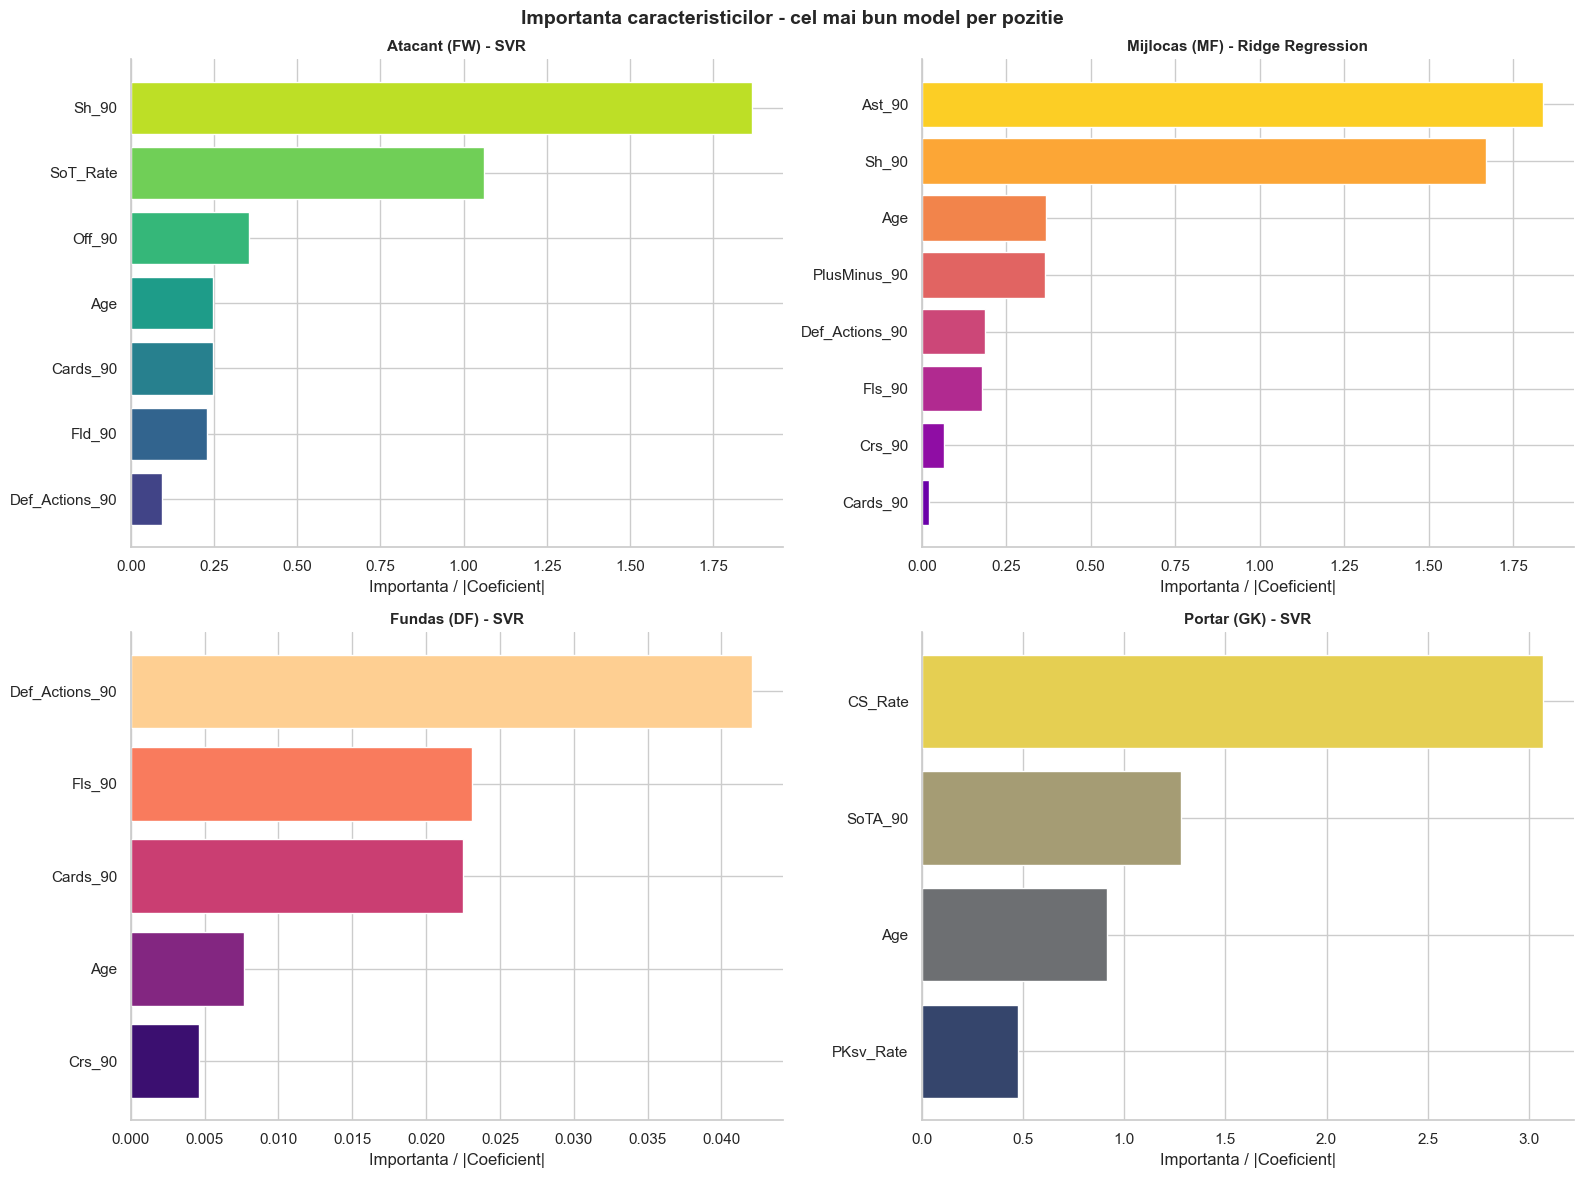

In [ ]:
def plot_feature_importance(model, features, title, ax, color='viridis'):
    if hasattr(model, 'feature_importances_'):
        imp = pd.DataFrame({'Caracteristica': features,
                            'Importanta': model.feature_importances_})
    elif hasattr(model, 'coef_'):
        coef = np.abs(model.coef_).flatten()  # <-- .flatten() rezolva eroarea
        imp = pd.DataFrame({'Caracteristica': features, 'Importanta': coef})
    else:
        ax.text(0.5, 0.5, 'Feature importance\nnu este disponibila',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title, fontsize=11)
        return

    imp = imp.sort_values('Importanta', ascending=True)
    ax.barh(imp['Caracteristica'], imp['Importanta'],
            color=plt.cm.get_cmap(color)(np.linspace(0.2, 0.9, len(imp))))
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Importanta / |Coeficient|')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Importanta caracteristicilor - cel mai bun model per pozitie',
             fontsize=14, fontweight='bold')

config_importance = [
    (rez_fw,    models_fw,    features_fw, 'Atacant (FW)',   'viridis', axes[0, 0]),
    (rez_mf,    models_mf,    features_mf, 'Mijlocas (MF)',  'plasma',  axes[0, 1]),
    (rez_df_ml, models_df,    features_df, 'Fundas (DF)',    'magma',   axes[1, 0]),
    (rez_gk,    models_gk,    features_gk, 'Portar (GK)',    'cividis', axes[1, 1]),
]

for rez, models, feats, label, cmap, ax in config_importance:
    if rez is not None:
        best_name = rez.iloc[0]['Model']
        best_model = models[best_name]['model']
        plot_feature_importance(best_model, feats, f'{label} - {best_name}', ax, cmap)

plt.tight_layout()
plt.savefig("grafic_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Top 5 jucători per poziție

Topul e bazat pe **predictia modelului cel mai bun** (cat de mult prezice modelul ca va performa jucatorul), nu pe scorul brut din date.

In [ ]:
config_top5 = {
    'GK': {'target': 'Save%', 'features': features_gk, 'rez': rez_gk,    'models': models_gk,  'label': 'Portari',   'color': '#4e79a7'},
    'DF': {'target': '+/-90', 'features': features_df, 'rez': rez_df_ml,  'models': models_df,  'label': 'Fundasi',   'color': '#59a14f'},
    'MF': {'target': 'G+A',   'features': features_mf, 'rez': rez_mf,     'models': models_mf,  'label': 'Mijlocasi', 'color': '#f28e2b'},
    'FW': {'target': 'Gls_90','features': features_fw, 'rez': rez_fw,     'models': models_fw,  'label': 'Atacanti',  'color': '#e15759'},
}

df_map = {
    'GK': df_gk,
    'DF': df_df,
    'MF': df_mf,
    'FW': df_fw,
}

top5_toate = {}

for pos, cfg in config_top5.items():
    df_pos = df_map[pos].dropna(subset=cfg['features'] + [cfg['target']]).copy()
    best_name  = cfg['rez'].iloc[0]['Model']
    best_model = cfg['models'][best_name]['model']

    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_all  = df_pos[cfg['features']].values
    if best_name in ['Ridge Regression', 'Lasso Regression', 'ElasticNet', 'SVR', 'KNN Regression']:
        X_scaled = scaler.fit_transform(X_all)
        df_pos['Predicted'] = best_model.predict(X_scaled)
    else:
        df_pos['Predicted'] = best_model.predict(X_all)

    cols_afisare = ['Player', 'Squad', 'Comp', 'Age', cfg['target'], 'Predicted']
    cols_afisare = [c for c in cols_afisare if c in df_pos.columns]
    top5 = df_pos.nlargest(5, 'Predicted')[cols_afisare].reset_index(drop=True)
    top5.index += 1
    top5.columns = [c if c != 'Predicted' else f'Predicted_{cfg["target"]}' for c in top5.columns]
    top5_toate[pos] = top5

    print(f'\n=== Top 5 {cfg["label"]} (predictie {cfg["target"]} — model: {best_name}) ===')
    display(top5)


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Top 5 jucatori per pozitie - Sezon 2025/2026 (ranking dupa predictia modelului)',
             fontsize=14, fontweight='bold')

for ax, (pos, cfg) in zip(axes.flatten(), config_top5.items()):
    top5     = top5_toate[pos]
    pred_col = [c for c in top5.columns if c.startswith('Predicted')][0]
    bars = ax.barh(top5['Player'][::-1], top5[pred_col][::-1],
                   color=cfg['color'], alpha=0.88, edgecolor='white', linewidth=0.6)
    for bar, val in zip(bars, top5[pred_col][::-1]):
        ax.text(bar.get_width() * 0.97, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', ha='right', fontsize=10,
                color='white', fontweight='bold')
    ax.set_title(f'{cfg["label"]} — predictie {cfg["target"]}', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'Predicted {cfg["target"]}')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("grafic_top5.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Salvarea rezultatelor

In [ ]:
with pd.ExcelWriter('rezultate_brute_modele.xlsx') as writer:
    for pos_name, rez in rez_dict.items():
        if rez is not None:
            sheet = pos_name.replace('(', '').replace(')', '').replace(' ', '_').replace('+','plus').replace('/','_')[:31]
            rez.to_excel(writer, sheet_name=sheet, index=True)

with pd.ExcelWriter('top5_jucatori_pozitii.xlsx') as writer:
    pozitii_label = {'GK': 'Portari', 'DF': 'Fundasi', 'MF': 'Mijlocasi', 'FW': 'Atacanti'}
    for pos, top5 in top5_toate.items():
        top5.to_excel(writer, sheet_name=pozitii_label[pos], index=True)

df.to_csv('players-final.csv', index=False)

print('Fisierele au fost salvate:')
print('   - rezultate_brute_modele.xlsx')
print('   - top5_jucatori_pozitii.xlsx')
print('   - players-final.csv')

Fisierele au fost salvate:
   - rezultate_brute_modele.xlsx
   - top5_jucatori_pozitii.xlsx
   - players-final.csv


In [9]:
[c for c in df.columns if any(x in c.lower() for x in ['sh', 'sot', 'gls', 'g-pk', 'goal', 'att', 'shot'])]

['Gls',
 'G-PK',
 'PKatt',
 'SoTA',
 'Sh',
 'SoT',
 'SoT%',
 'Sh/90',
 'SoT/90',
 'G/Sh',
 'G/SoT',
 'Sh_90',
 'SoT_Rate',
 'SoTA_90']